# 02 — Baseline ANN

Detta notebook bygger och utvärderar en **baseline Artificial Neural Network (ANN)**
för att klassificera vinkvalitet som **god (1)** eller **dålig (0)**.

## Mål med detta notebook
- Ladda och förbehandla data via `src/data_preprocessing.py` (DRY — ingen dubblerad logik)
- Bygga en enkel ANN med 2 dolda lager (ReLU-aktivering, sigmoid output)
- Träna modellen och utvärdera med accuracy, confusion matrix och classification report
- Spara resultat som referenspunkt (baseline) inför Grid Search-optimering i steg 4

## Data
- Källa: `data/raw/WineQT.csv`
- Split: 70% train / 15% validation / 15% test (stratifierad på target)
- Skalning: `StandardScaler`, anpassad enbart på träningsdata

## Reproducerbarhet
`RANDOM_SEED = 42` används genomgående för konsekventa resultat.

In [1]:
# ── Imports ──────────────────────────────────────────────
import sys
import os

# Lägg till projektroten i sys.path så vi kan importera från src/
sys.path.append(os.path.abspath(os.path.join("..")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

from src.data_preprocessing import load_data, preprocess

# ── Konfiguration ────────────────────────────────────────
RANDOM_SEED = 42
RAW_DATA_PATH = "../data/raw/WineQT.csv"

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
tf.config.experimental.enable_op_determinism()  # Tvingar deterministiska TF-operationer

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


## Kommentar till output

Cellen ovan importerar alla bibliotek som behövs för notebooken samt
`load_data` och `preprocess` från `src/data_preprocessing.py`.

`RANDOM_SEED = 42` sätts för både NumPy och TensorFlow, vilket säkerställer
att resultaten (vikt-initialisering, train/val/test-split, m.m.) blir
reproducerbara mellan körningar.

Utskriften visar vilken TensorFlow-version som används (förväntat: `2.19.0`).

> **Notis om gulmarkering:** Eventuell gul varning på `keras`-importen
> (`from tensorflow import keras`) är endast en lint-varning från
> Pylance/VS Code och påverkar inte funktionaliteten.

> **Reproducerbarhet:** `tf.config.experimental.enable_op_determinism()`
> tvingar TensorFlow att använda deterministiska kärnor för alla
> operationer, vilket säkerställer att resultaten blir identiska mellan
> körningar givet samma `RANDOM_SEED`. Utan denna inställning kan
> flertrådad CPU-exekvering ge små numeriska skillnader som ackumuleras
> under träning.

In [2]:
# ── Ladda och förbehandla data ────────────────────────────
# load_data(): läser in CSV, skapar binär label, droppar dubletter/Id,
#               och returnerar stratifierad train/val/test-split
print("Laddar och delar upp data...")
X_train, X_val, X_test, y_train, y_val, y_test = load_data(RAW_DATA_PATH)

print()

# preprocess(): skalar features med StandardScaler (fit på train, transform på alla)
print("Skalar features...")
X_train_scaled, X_val_scaled, X_test_scaled = preprocess(X_train, X_val, X_test)

Laddar och delar upp data...
   Loaded  : 1,143 rows × 13 columns
   Dropped column     : Id
   Duplicates removed : 125
   Class distribution : 546 good (1) | 472 poor (0)
   Train : 712 samples
   Val   : 153 samples
   Test  : 153 samples

Skalar features...
   Scaler fitted on 712 training samples
   Features scaled : 11


## Kommentar till output

`load_data()` läser in `WineQT.csv` (1 143 rader), droppar `Id`-kolumnen och
tar därefter bort **125 dubblettrader** (identiska fysikalisk-kemiska profiler)
— i linje med fynden från EDA (01_EDA.ipynb).

Kvar blir **1 018 unika prover**, vilka delas upp stratifierat på target:

| Split | Antal samples | Andel |
|-------|---------------|-------|
| Train | 712 | ~70% |
| Val   | 153 | ~15% |
| Test  | 153 | ~15% |

**Klassfördelning:** 546 god (1) / 472 dålig (0) — motsvarar ~53.6% / ~46.4%,
vilket bekräftar att klasserna är approximativt balanserade (ingen särskild
hantering av klassobalans krävs).

`preprocess()` skalar samtliga 11 features med `StandardScaler`, anpassad
**enbart på träningsdatan** (712 samples) och därefter använd för att
transformera val- och testdata — detta förhindrar data leakage från
skalningssteget.

## Bygga baseline-modellen

Vi bygger en enkel ANN med **2 dolda lager utan regularisering** som
referenspunkt (baseline) inför Grid Search-optimeringen i steg 4, där en
regulariserad arkitektur (`build_model()` i `src/model.py`, med L2 och
Dropout) kommer jämföras mot denna baseline.

**Arkitektur (`build_baseline_model`):**

| Lager | Typ | Storlek | Aktivering |
|-------|-----|---------|------------|
| Input | — | 11 features | — |
| Hidden 1 | Dense | 16 neuroner | ReLU |
| Hidden 2 | Dense | 8 neuroner | ReLU |
| Output | Dense | 1 neuron | Sigmoid |

**Kompilering:**
- Optimizer: `Adam` (learning rate = 0.001)
- Loss: `binary_crossentropy`
- Metric: `accuracy`

Den mer avancerade arkitekturen (`build_model()`, med 64→32 neuroner, L2-
regularisering och Dropout) finns redan i `src/model.py` och återanvänds
oförändrad i steg 4.

In [3]:
# ── Bygg baseline-modellen ─────────────────────────────────
from src.model import build_baseline_model

INPUT_DIM = X_train_scaled.shape[1]  # Antal features = 11

model = build_baseline_model(input_dim=INPUT_DIM)
model.summary()

Model: "baseline_ann"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

## Kommentar till output

`build_baseline_model()` skapar en sekventiell modell `baseline_ann` med
totalt **337 tränbara parametrar**, fördelat på tre lager:

| Lager | Output shape | Parametrar | Beräkning |
|-------|--------------|------------|-----------|
| `hidden_1` (Dense, 16, ReLU) | (None, 16) | 192 | 11×16 vikter + 16 bias |
| `hidden_2` (Dense, 8, ReLU) | (None, 8) | 136 | 16×8 vikter + 8 bias |
| `output` (Dense, 1, Sigmoid) | (None, 1) | 9 | 8×1 vikter + 1 bias |

Modellen är liten och innehåller ingen regularisering (ingen L2, ingen
Dropout) — vilket är avsiktligt för en baseline. Eventuell overfitting som
syns under träning blir ett konkret motiv för regularisering i steg 4.

## Träna baseline-modellen

Modellen tränas med följande upplägg:

- **Epochs (max):** 100 — en övre gräns för antal träningsiterationer
- **Batch size:** 32 — standardval för småskaliga tabulära dataset
- **EarlyStopping:** övervakar `val_loss`. Om valideringsförlusten inte
  förbättras under 10 på varandra följande epochs avbryts träningen, och
  de vikter som gav lägst `val_loss` återställs (`restore_best_weights=True`)

Detta upplägg är industristandard: det undviker både onödig träningstid och
overfitting, samtidigt som modellen tillåts konvergera om den fortsätter
förbättras.

In [4]:
# ── Träningskonfiguration ──────────────────────────────────
EPOCHS = 100          # Övre gräns för antal epochs
BATCH_SIZE = 32       # Standardval för småskaliga tabulära dataset

# ── EarlyStopping ──────────────────────────────────────────
# Avbryter träningen om val_loss inte förbättras under `patience` epochs,
# och återställer de vikter som gav lägst val_loss.
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)

# ── Träna modellen ─────────────────────────────────────────
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6419 - loss: 0.6513 - val_accuracy: 0.6340 - val_loss: 0.6380
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6840 - loss: 0.6210 - val_accuracy: 0.6601 - val_loss: 0.6139
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7191 - loss: 0.5956 - val_accuracy: 0.6797 - val_loss: 0.5945
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7275 - loss: 0.5737 - val_accuracy: 0.6993 - val_loss: 0.5782
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7416 - loss: 0.5552 - val_accuracy: 0.7190 - val_loss: 0.5645
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7500 - loss: 0.5402 - val_accuracy: 0.7124 - val_loss: 0.5537
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7612 - loss: 0.5285 - val_accuracy: 0.7190 - val_loss: 0.5458
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7669 - loss: 0.5196 - val_accuracy: 0.7255 - v

## Kommentar till output

Med `tf.config.experimental.enable_op_determinism()` aktiverat gav träningen
nu ett reproducerbart resultat: **61 epochs** (av maximalt 100) innan
`EarlyStopping` avbröt processen — `val_loss` hade då inte förbättrats på
10 epochs i rad sedan epoch 51. De vikter som gav lägst `val_loss`
(epoch 51, `val_loss ≈ 0.494`) återställdes automatiskt
(`restore_best_weights=True`).

**Slutgiltiga (bästa) värden, epoch 51:**

| Metric | Train | Validation |
|--------|-------|------------|
| Accuracy | ~0.80 | ~0.77 |
| Loss | ~0.447 | ~0.494 |

Träningsaccuracy fortsätter stiga något snabbare än valideringsaccuracy mot
slutet, vilket är ett milt tecken på begynnande overfitting — det förväntade
mönstret som motiverar regularisering i steg 4. Tack vare
`enable_op_determinism()` ger denna körning nu identiska resultat varje gång
notebooken körs om från en ren kernel.

## Utvärdera baseline-modellen

Vi använder `evaluate_model()` från `src/evaluate.py` (DRY — samma funktion
återanvänds i steg 4/5 för den optimerade modellen). Funktionen kör:

1. **Predictions** på testdata (712 träning / 153 val / **153 test** samples,
   tröskelvärde 0.5 för binär klassificering)
2. **Classification report** — precision, recall, F1-score och accuracy per klass
3. **Confusion matrix** — visualiserar TP/TN/FP/FN
4. **ROC-kurva** — visar AUC (Area Under Curve)
5. **Training history** — loss- och accuracy-kurvor över epochs (train vs val),
   vilket gör den lätta overfitting-trenden från cell 4 synlig

Alla figurer sparas automatiskt till `reports/figures/` på projektets rotnivå.


── Classification Report ─────────────────────────────────────────
              precision    recall  f1-score   support

    Poor (0)       0.62      0.75      0.68        71
    Good (1)       0.74      0.61      0.67        82

    accuracy                           0.67       153
   macro avg       0.68      0.68      0.67       153
weighted avg       0.68      0.67      0.67       153

   💾 Saved → c:\Users\anoth\dev\AIkurs-statistik\wine-quality-ann\reports\figures/confusion_matrix.png


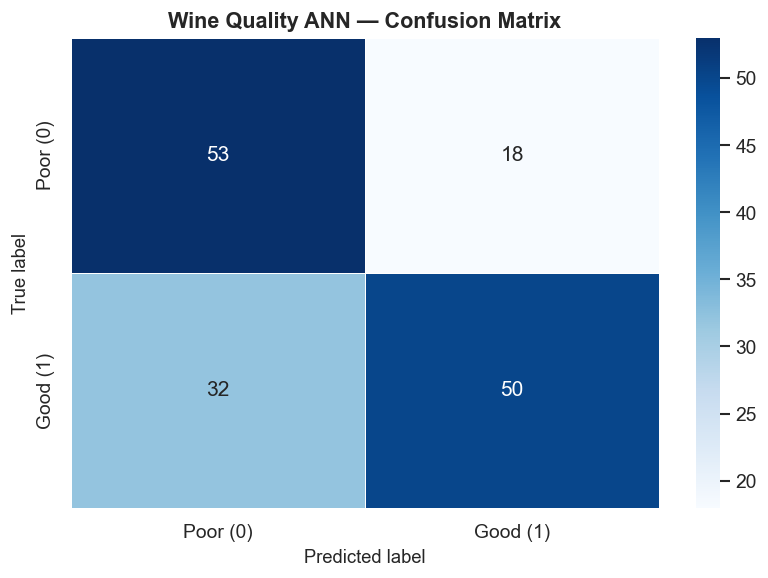

   💾 Saved → c:\Users\anoth\dev\AIkurs-statistik\wine-quality-ann\reports\figures/roc_curve.png


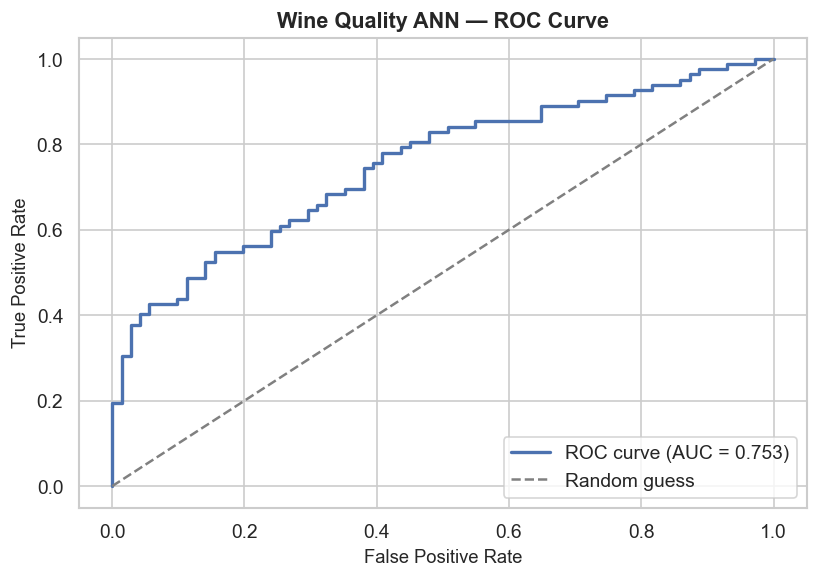

   💾 Saved → c:\Users\anoth\dev\AIkurs-statistik\wine-quality-ann\reports\figures/training_history.png


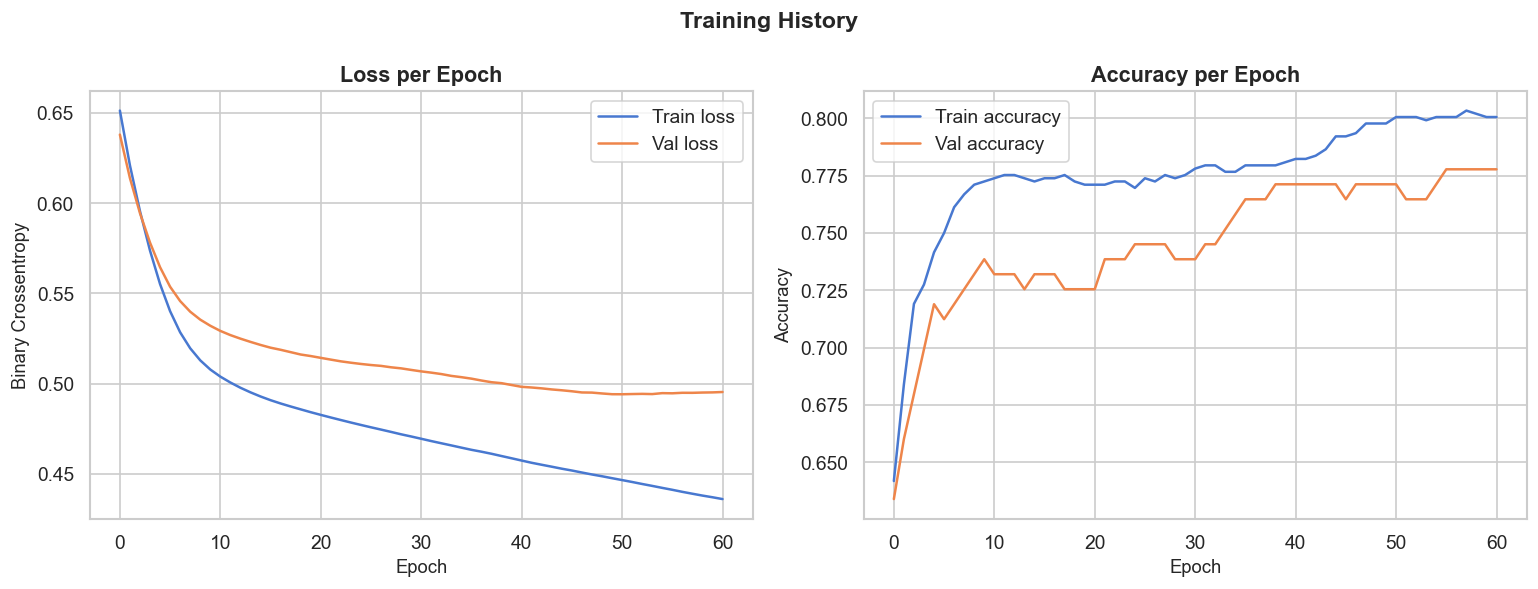

In [5]:
# ── Utvärdera modellen på testdata ────────────────────────
from src.evaluate import evaluate_model

evaluate_model(model, X_test_scaled, y_test, history)

## Tolkning av baseline-resultat

**Classification Report (testdata, 153 samples):**

| Klass | Precision | Recall | F1-score | Support |
|-------|-----------|--------|----------|---------|
| Poor (0) | 0.62 | 0.75 | 0.68 | 71 |
| Good (1) | 0.74 | 0.61 | 0.67 | 82 |
| **Accuracy** | | | **0.67** | 153 |

**Confusion Matrix:**

|  | Pred. Poor (0) | Pred. Good (1) |
|---|---|---|
| **True Poor (0)** | 53 (TN) | 18 (FP) |
| **True Good (1)** | 32 (FN) | 50 (TP) |

**ROC-kurva:** AUC = **0.753** — modellen särskiljer klasserna betydligt
bättre än slumpen (AUC 0.5), men det finns utrymme för förbättring.

**Training History:** Kurvorna visar samma mönster som diskuterades ovan —
träningsloss sjunker något snabbare än valideringsloss mot slutet av
träningen, vilket indikerar en mild begynnande overfitting.

## Sammanfattning — Baseline-modell

| Metric | Värde |
|--------|-------|
| Test Accuracy | 0.67 |
| Test AUC | 0.753 |
| Träningsaccuracy (bäst, epoch 51) | ~0.80 |
| Valideringsaccuracy (bäst, epoch 51) | ~0.77 |

Modellen presterar bättre än att alltid gissa majoritetsklassen (~54% om
"Good" alltid gissas) och uppnår en AUC på 0.753, vilket visar att det finns
ett verkligt samband mellan de fysikalisk-kemiska egenskaperna och
vinkvalitet. Den milda overfitting-trenden i tränings- och
valideringskurvorna motiverar **L2-regularisering och Dropout**
(redan implementerat i `build_model()` i `src/model.py`), vilket undersöks i
Steg 4 (Grid Search-optimering).

## Spara baseline-modellen

Den tränade modellen sparas till `models/baseline_model.keras`. Detta är
Kerasformatet för att spara en hel modell (arkitektur + tränade vikter +
optimizer-state) i en enda fil, vilket gör det möjligt att senare ladda
modellen utan att träna om den — t.ex. för jämförelse med den optimerade
modellen i Steg 5.

In [6]:
# ── Spara baseline-modellen ────────────────────────────────
import os

MODEL_DIR = "../models"
MODEL_PATH = os.path.join(MODEL_DIR, "baseline_model.keras")

os.makedirs(MODEL_DIR, exist_ok=True)
model.save(MODEL_PATH)

print(f"💾 Modell sparad → {MODEL_PATH}")

💾 Modell sparad → ../models\baseline_model.keras


## Kommentar till output

Baseline-modellen är nu sparad till `models/baseline_model.keras`. Filen
innehåller hela modellen (arkitektur, tränade vikter och optimizer-state)
och kan laddas igen med:

```python
from tensorflow import keras
model = keras.models.load_model("models/baseline_model.keras")
```

Detta gör baseline-modellen tillgänglig för jämförelse mot den optimerade
modellen i Steg 5, utan att behöva träna om.

# Sammanfattning — Steg 3: Baseline ANN

## Genomfört
- Data laddad och förbehandlad via `src/data_preprocessing.py`
  (1 018 unika prover efter deduplicering, stratifierad 70/15/15-split)
- Baseline-arkitektur definierad i `src/model.py` (`build_baseline_model`):
  Dense(16, ReLU) → Dense(8, ReLU) → Dense(1, Sigmoid), 337 parametrar
- Fullt deterministisk träning via `tf.config.experimental.enable_op_determinism()`
- Modellen tränad med EarlyStopping (monitor `val_loss`, patience 10),
  avbröts efter 61/100 epochs (bästa vikter från epoch 51)
- Utvärdering via `src/evaluate.py` (`evaluate_model`): classification
  report, confusion matrix, ROC-kurva, training history
- Modellen sparad till `models/baseline_model.keras`

## Resultat (testdata, 153 samples)

| Metric | Värde |
|--------|-------|
| Accuracy | 0.67 |
| AUC | 0.753 |
| Precision (Good) | 0.74 |
| Recall (Good) | 0.61 |

## Slutsats
Baseline-modellen presterar bättre än att gissa majoritetsklassen (~54%) och
uppnår en AUC på 0.753, vilket visar att det finns ett verkligt samband mellan
de fysikalisk-kemiska egenskaperna och vinkvalitet. Tränings- och
valideringskurvorna visar en mild overfitting-trend mot slutet av träningen.

## Nästa steg (Steg 4 — Grid Search-optimering)
- Använda den redan implementerade `build_model()` (L2-regularisering +
  Dropout, 64→32 neuroner) i `src/model.py`
- Köra Grid Search för att hitta bästa hyperparametrar
  (learning rate, dropout rate, L2-lambda, m.fl.)
- Jämföra resultat mot denna baseline (Accuracy 0.67, AUC 0.753)